# MFE 230X — High-Frequency Finance — Homework 1

**NASDAQ TotalView-ITCH (Databento) and the two supplied Currency files**

Instructors: Terrence Hendershott, Dmitry Livdan · Fall 2026  
Authors: Alexandre Marthan · Elias Roubache · Jean Jacob · Matthieu Pascal · Elouan Bahri

| Market | Instruments | Sample session |
|---|---|---|
| NASDAQ | AAPL (large cap), GPRO (small cap) | 2019-12-30, 09:30–16:00 ET |
| Currency | EUR/USD, USD/JPY, EUR/JPY | 2012-01-25, 09:30–16:00 (file timestamps) |

The stock and currency dates differ because Homework 1 asks for Databento on the equity side and the two course Data Folder files on the currency side. This notebook does not substitute another FX vendor.

**Why these two stocks.** The assignment asks for two NASDAQ names that differ in market capitalization. AAPL is a large-cap, high-turnover name; GPRO (GoPro) is a small-cap name trading near $4.30 on this day. The point of the pair is not that we screened a universe — it is that the same book-construction and impact code can be read against a thick name and a thin, tick-constrained name. If adverse-selection costs scale with how easily a dealer averages informed flow against noise trades, the two books should not look alike. Currency pairs are the assigned EUR triangle, not a choice.


## Methodology fixed before looking at the results

- **Stocks:** MBP-10 supplies trades and the top ten price levels; MBO supplies strict new-order counts. Databento timestamps are converted from UTC to New York and all work uses exchange-event time (`ts_event`). The 10-minute pre-open MBP-10 buffer seeds the 09:30 book.
- **Orders:** `n_orders` counts genuine ITCH additions. Databento represents a replace as a `C+A` pair with the same symbol, channel and sequence; the replacement-generated `A` is excluded. The raw number of `A` messages is retained as a diagnostic.
- **Currency:** each physical CSV row may contain one, two or three pair blocks. Each populated block is converted to a long event. In the order file, flag 0 is bid, flag 1 is ask, `SIZE` replaces the entire level quantity, and zero removes the level. Integer price ticks are used as book keys.
- **Trades and dollars:** stock notional is `price × size`. Currency uses `TOTAL_SIZE` as the complete transaction quantity: EUR/USD is already USD notional; USD/JPY size is USD; EUR/JPY JPY notional is converted with the same-second USD/JPY midpoint. Currency flag 0 maps to trade sign −1 and flag 1 to +1. Databento sides `A/B` map to −1/+1; unsigned `N` trades remain in volume/OHLC/VWAP but are omitted from signed-impact regressions.
- **Liquidity:** spread and bid/ask depth are piecewise-constant and averaged with exact event-time weights in each minute. These are **exchange BBO** numbers from NASDAQ TotalView, not the NBBO. A protected National Best Bid/Offer can be better than NASDAQ alone; we do not have the other venues. Depth at twice the daily average spread sums bid size at prices ≥ `mid − 2×avg spread` and ask size at prices ≤ `mid + 2×avg spread`, each side separately. That band is the size you can lift or hit before walking more than two typical spreads. The assignment notes it is zero when the quoted spread itself exceeds twice the daily average. `DEPTH_BAND_MULTIPLIER` can be changed if the instructors issue a different convention.
- **5-second impact:** within every minute, regress `(mid(t+5s) − mid(t))/mid(t)` on a constant and the current trade sign. For Databento, `mid(t)` is the pre-trade BBO carried on the `T` record. Otherwise it is the latest book state strictly before the trade; `mid(t+5s)` is the latest state at or before the horizon. A minute is left blank when there are not enough signed trades to identify the slope.
- **Prices and returns:** the last midpoint and transaction price in each 1-second/1-minute interval are used, with previous-tick carry-forward after the first valid observation. Returns are log differences; realized variance is the sum of squared intraday returns. Autocorrelations are reported at lags 0–10 (lag 0 equals 1 by construction).
- **Triangular arbitrage:** both executable bid/ask loops are tested on synchronized one-second books. A second is counted only if every leg has a strictly positive, uncrossed BBO (`ask > bid > 0`). Frequency, consecutive duration, binding BBO quantity (EUR), and frictionless marked profit are reported. Latency, fees, and whether the quotes were firm are not in these files.
- **Timing:** every load and analysis block is timed with `time.perf_counter`. The last section compares those wall times with how long an apparent arbitrage actually lasts.


In [1]:
import importlib.util
import subprocess
import sys

required = {
    "databento": "databento",
    "matplotlib": "matplotlib",
    "statsmodels": "statsmodels",
}
missing = [package for module, package in required.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

from pathlib import Path
import time
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")
plt.style.use("seaborn-v0_8-whitegrid")



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## Data pipeline

The following cell is deliberately self-contained so the notebook can be uploaded to Datalore without a separate local Python module. DBN files are streamed in chunks; the compressed files do not need to be unzipped.


In [2]:
from __future__ import annotations

from collections import defaultdict
from pathlib import Path
import time

import numpy as np
import pandas as pd


TZ = "America/New_York"
SESSION_START = "09:30:00"
SESSION_END = "16:00:00"
STOCKS = ["AAPL", "GPRO"]
FX_PAIRS = ["EURUSD", "USDJPY", "EURJPY"]
FX_PRICE_SCALE = {"EURUSD": 100_000, "USDJPY": 1_000, "EURJPY": 1_000}
# Discussion Session 02, slide "Depth at twice average spread":
# ask prices <= midquote + 2*average spread, symmetrically for bids.
DEPTH_BAND_MULTIPLIER = 2.0
TIMINGS: dict[str, float] = {}


def time_block(name: str):
    """Record wall-clock seconds for a named load or analysis step in TIMINGS."""

    class _Timer:
        def __enter__(self) -> None:
            self._start = time.perf_counter()

        def __exit__(self, exc_type, exc, tb) -> None:
            TIMINGS[name] = time.perf_counter() - self._start

    return _Timer()


def session_bounds(date: str) -> tuple[pd.Timestamp, pd.Timestamp]:
    """Return the regular-session [09:30, 16:00) timestamps for ``date``."""
    return (
        pd.Timestamp(f"{date} {SESSION_START}"),
        pd.Timestamp(f"{date} {SESSION_END}"),
    )


def session_grid(date: str, freq: str) -> pd.DatetimeIndex:
    """Build a left-closed regular-session grid at the requested frequency."""
    start, end = session_bounds(date)
    return pd.date_range(start, end, freq=freq, inclusive="left")


def _state_events_for_session(
    events: pd.DataFrame, date: str, fields: list[str]
) -> pd.DataFrame:
    """Return state-change rows clipped to the session, including a 09:30 seed."""
    start, end = session_bounds(date)
    state = events[fields].sort_index(kind="stable")
    state = state[~state.index.duplicated(keep="last")]
    seed = state.loc[state.index <= start].tail(1).copy()
    if seed.empty:
        if state.loc[(state.index > start) & (state.index < end)].empty:
            return state.iloc[0:0]
        seed = pd.DataFrame([[np.nan] * len(fields)], index=[start], columns=fields)
    else:
        seed.index = pd.DatetimeIndex([start])
    inside = state.loc[(state.index > start) & (state.index < end)]
    return pd.concat([seed, inside]).sort_index(kind="stable")


def _time_weighted_average(
    events: pd.DataFrame, field: str, date: str
) -> float:
    """Session-wide time-weighted mean of a piecewise-constant quote field."""
    state = _state_events_for_session(events, date, [field])
    if state.empty:
        return np.nan
    _, end = session_bounds(date)
    boundaries = state.index.to_numpy(dtype="datetime64[ns]").astype("int64")
    next_boundaries = np.r_[boundaries[1:], end.value]
    duration_s = (next_boundaries - boundaries) / 1e9
    values = state[field].to_numpy(dtype=float)
    valid = np.isfinite(values) & (duration_s > 0)
    return float(np.average(values[valid], weights=duration_s[valid])) if valid.any() else np.nan


def _time_weighted_minute(
    events: pd.DataFrame, fields: list[str], date: str
) -> pd.DataFrame:
    """Integrate piecewise-constant state exactly over each one-minute bin."""
    state = _state_events_for_session(events, date, fields)
    minute_index = session_grid(date, "1min")
    result = pd.DataFrame(np.nan, index=minute_index, columns=fields, dtype=float)
    if state.empty:
        return result

    start, end = session_bounds(date)
    event_ns = state.index.view("i8")
    end_ns = end.value
    next_ns = np.r_[event_ns[1:], end_ns]
    values = state[fields].to_numpy(dtype=float)
    valid = np.isfinite(values)
    segment_ns = (next_ns - event_ns)[:, None]
    cumulative = np.vstack([
        np.zeros(len(fields)),
        np.cumsum(np.where(valid, values, 0.0) * segment_ns, axis=0),
    ])
    valid_cumulative = np.vstack([
        np.zeros(len(fields)),
        np.cumsum(valid.astype(float) * segment_ns, axis=0),
    ])

    boundary_ns = pd.date_range(start, end, freq="1min").view("i8")
    positions = np.searchsorted(event_ns, boundary_ns, side="right") - 1
    area = np.empty((len(boundary_ns), len(fields)), dtype=float)
    valid_area = np.empty((len(boundary_ns), len(fields)), dtype=float)
    for i, (boundary, pos) in enumerate(zip(boundary_ns, positions)):
        if pos < 0:
            area[i] = np.nan
            valid_area[i] = np.nan
        elif pos >= len(event_ns):
            area[i] = cumulative[-1]
            valid_area[i] = valid_cumulative[-1]
        else:
            partial = boundary - event_ns[pos]
            area[i] = cumulative[pos] + np.where(valid[pos], values[pos], 0.0) * partial
            valid_area[i] = valid_cumulative[pos] + valid[pos].astype(float) * partial
    numerator = np.diff(area, axis=0)
    denominator = np.diff(valid_area, axis=0)
    result.loc[:, fields] = np.divide(
        numerator,
        denominator,
        out=np.full_like(numerator, np.nan),
        where=denominator > 0,
    )
    return result


def _local_event_index(frame: pd.DataFrame) -> pd.DataFrame:
    """Use exchange-event time, convert UTC to New York, and remove the timezone."""
    out = frame.copy()
    if "ts_event" not in out.columns:
        raise KeyError("Databento frame does not contain ts_event")
    idx = pd.DatetimeIndex(pd.to_datetime(out["ts_event"], utc=True))
    out.index = idx.tz_convert(TZ).tz_localize(None)
    out.index.name = "ts"
    return out


def _dbn_frame_iterator(path: str | Path, chunk_records: int = 250_000):
    import databento as db

    store = db.DBNStore.from_file(path)
    frames = store.to_df(
        price_type="float",
        pretty_ts=True,
        map_symbols=True,
        count=chunk_records,
    )
    yield from frames


def _finish_databento_book(
    quote_parts: list[pd.DataFrame],
    date: str,
    avg_spread: float,
    band_multiplier: float = DEPTH_BAND_MULTIPLIER,
) -> pd.DataFrame:
    """Build a 1-second NASDAQ book, BBO stats, and 2×-spread band depth."""
    if not quote_parts:
        return pd.DataFrame(index=session_grid(date, "1s"))

    q = pd.concat(quote_parts).sort_index(kind="stable")
    q = q.groupby(q.index.floor("1s"), sort=True).tail(1)
    q.index = q.index.floor("1s")
    q = q[~q.index.duplicated(keep="last")]
    grid = session_grid(date, "1s")
    seed = q.loc[q.index <= grid[0]].tail(1).copy()
    if not seed.empty:
        seed.index = pd.DatetimeIndex([grid[0]])
        q = pd.concat([seed, q.loc[q.index > grid[0]]]).sort_index(kind="stable")
        q = q[~q.index.duplicated(keep="last")]
    q = q.reindex(grid).ffill()

    q["bid"] = q["bid_px_00"]
    q["ask"] = q["ask_px_00"]
    q["bidsz"] = q["bid_sz_00"].astype(float)
    q["asksz"] = q["ask_sz_00"].astype(float)
    q["mid"] = (q["bid"] + q["ask"]) / 2.0
    q["spread"] = q["ask"] - q["bid"]
    valid = (
        q["bid"].gt(0)
        & q["ask"].gt(q["bid"])
        & np.isfinite(q["mid"])
    )
    q.loc[~valid, ["bid", "ask", "bidsz", "asksz", "mid", "spread"]] = np.nan
    q[["bid", "ask", "bidsz", "asksz", "mid", "spread"]] = q[
        ["bid", "ask", "bidsz", "asksz", "mid", "spread"]
    ].ffill()

    lower = q["mid"] - band_multiplier * avg_spread
    upper = q["mid"] + band_multiplier * avg_spread
    bid_depth = np.zeros(len(q), dtype=float)
    ask_depth = np.zeros(len(q), dtype=float)
    for level in range(10):
        bid_px = q[f"bid_px_{level:02d}"]
        ask_px = q[f"ask_px_{level:02d}"]
        bid_sz = q[f"bid_sz_{level:02d}"].fillna(0.0)
        ask_sz = q[f"ask_sz_{level:02d}"].fillna(0.0)
        bid_depth += np.where(bid_px.ge(lower) & bid_px.gt(0), bid_sz, 0.0)
        ask_depth += np.where(ask_px.le(upper) & ask_px.gt(0), ask_sz, 0.0)

    q["bid_depth_2x"] = bid_depth
    q["ask_depth_2x"] = ask_depth
    q["depth_2x"] = q["bid_depth_2x"] + q["ask_depth_2x"]
    q["bid_depth"] = q["bidsz"]
    q["ask_depth"] = q["asksz"]
    q["depth"] = q["bidsz"] + q["asksz"]
    q["avg_spread_day"] = avg_spread
    q["depth_band_multiplier"] = band_multiplier
    q["depth_2x_may_be_truncated"] = (
        q["bid_px_09"].ge(lower) | q["ask_px_09"].le(upper)
    )
    return q


def load_databento_stocks(
    mbp10_path: str | Path,
    mbo_path: str | Path,
    date: str = "2019-12-30",
    symbols: list[str] | tuple[str, ...] = tuple(STOCKS),
    chunk_records: int = 250_000,
) -> dict[str, dict[str, pd.DataFrame | pd.Series]]:
    """Load Databento MBP-10/MBO without materializing either full DBN at once."""
    symbols = list(symbols)
    start, end = session_bounds(date)
    seed_start = start - pd.Timedelta(minutes=15)
    level_cols = [
        col
        for level in range(10)
        for col in (
            f"bid_px_{level:02d}",
            f"ask_px_{level:02d}",
            f"bid_sz_{level:02d}",
            f"ask_sz_{level:02d}",
        )
    ]
    quote_parts: dict[str, list[pd.DataFrame]] = defaultdict(list)
    quote_event_parts: dict[str, list[pd.DataFrame]] = defaultdict(list)
    trade_parts: dict[str, list[pd.DataFrame]] = defaultdict(list)

    for raw in _dbn_frame_iterator(mbp10_path, chunk_records):
        chunk = _local_event_index(raw)
        chunk = chunk[(chunk.index >= seed_start) & (chunk.index < end)]
        if chunk.empty:
            continue
        for symbol in symbols:
            sub = chunk[chunk["symbol"] == symbol]
            if sub.empty:
                continue

            quote = sub[level_cols]
            quote = quote[
                quote["bid_px_00"].gt(0)
                & quote["ask_px_00"].gt(quote["bid_px_00"])
            ]
            if not quote.empty:
                reduced = quote.groupby(quote.index.floor("1s"), sort=False).tail(1)
                quote_parts[symbol].append(reduced)

                events = quote[
                    ["bid_px_00", "ask_px_00", "bid_sz_00", "ask_sz_00"]
                ].rename(
                    columns={
                        "bid_px_00": "bid",
                        "ask_px_00": "ask",
                        "bid_sz_00": "bidsz",
                        "ask_sz_00": "asksz",
                    }
                )
                events["mid"] = (events["bid"] + events["ask"]) / 2.0
                events["spread"] = events["ask"] - events["bid"]
                quote_event_parts[symbol].append(events)

            trades = sub[(sub["action"] == "T") & (sub.index >= start)]
            if not trades.empty:
                trades = trades[
                    ["price", "size", "side", "bid_px_00", "ask_px_00"]
                ].copy()
                trades.rename(columns={"size": "shares"}, inplace=True)
                trades["sign"] = trades["side"].map({"B": 1.0, "A": -1.0})
                valid_trade_bbo = (
                    trades["bid_px_00"].gt(0)
                    & trades["ask_px_00"].gt(trades["bid_px_00"])
                )
                trades["mid_at_trade"] = np.where(
                    valid_trade_bbo,
                    (trades["bid_px_00"] + trades["ask_px_00"]) / 2.0,
                    np.nan,
                )
                trades.drop(columns=["bid_px_00", "ask_px_00"], inplace=True)
                trades["px_qty"] = trades["price"] * trades["shares"]
                trades["dollar"] = trades["px_qty"]
                trade_parts[symbol].append(trades)

    quote_events_by_symbol: dict[str, pd.DataFrame] = {}
    avg_spreads: dict[str, float] = {}
    for symbol in symbols:
        quote_events = (
            pd.concat(quote_event_parts[symbol]).sort_index(kind="stable")
            if quote_event_parts[symbol]
            else pd.DataFrame(
                columns=["bid", "ask", "bidsz", "asksz", "mid", "spread"]
            )
        )
        if not quote_events.empty:
            changed = (
                quote_events[["bid", "ask", "bidsz", "asksz"]]
                .ne(quote_events[["bid", "ask", "bidsz", "asksz"]].shift())
                .any(axis=1)
            )
            quote_events = quote_events.loc[changed]
        quote_events_by_symbol[symbol] = quote_events
        avg_spreads[symbol] = _time_weighted_average(
            quote_events, "spread", date
        )

    # A second streaming pass computes exact event-time liquidity means without
    # retaining all 40 top-of-book level columns in memory.
    liquidity_parts: dict[str, list[pd.DataFrame]] = defaultdict(list)
    for raw in _dbn_frame_iterator(mbp10_path, chunk_records):
        chunk = _local_event_index(raw)
        chunk = chunk[(chunk.index >= seed_start) & (chunk.index < end)]
        if chunk.empty:
            continue
        for symbol in symbols:
            q = chunk.loc[chunk["symbol"] == symbol, level_cols].copy()
            q = q[q["bid_px_00"].gt(0) & q["ask_px_00"].gt(q["bid_px_00"])]
            if q.empty:
                continue
            mid = (q["bid_px_00"] + q["ask_px_00"]) / 2.0
            lower = mid - DEPTH_BAND_MULTIPLIER * avg_spreads[symbol]
            upper = mid + DEPTH_BAND_MULTIPLIER * avg_spreads[symbol]
            bid_2x = np.zeros(len(q), dtype=float)
            ask_2x = np.zeros(len(q), dtype=float)
            for level in range(10):
                bid_2x += np.where(
                    q[f"bid_px_{level:02d}"].ge(lower),
                    q[f"bid_sz_{level:02d}"],
                    0.0,
                )
                ask_2x += np.where(
                    q[f"ask_px_{level:02d}"].le(upper)
                    & q[f"ask_px_{level:02d}"].gt(0),
                    q[f"ask_sz_{level:02d}"],
                    0.0,
                )
            metrics = pd.DataFrame(index=q.index)
            metrics["spread"] = q["ask_px_00"] - q["bid_px_00"]
            metrics["bid_depth"] = q["bid_sz_00"].astype(float)
            metrics["ask_depth"] = q["ask_sz_00"].astype(float)
            metrics["depth"] = metrics["bid_depth"] + metrics["ask_depth"]
            metrics["bid_depth_2x"] = bid_2x
            metrics["ask_depth_2x"] = ask_2x
            metrics["depth_2x"] = bid_2x + ask_2x
            liquidity_parts[symbol].append(metrics)

    new_order_counts: dict[str, pd.Series] = {
        symbol: pd.Series(dtype="int64") for symbol in symbols
    }
    add_message_counts: dict[str, pd.Series] = {
        symbol: pd.Series(dtype="int64") for symbol in symbols
    }
    carry_cancel_key: tuple[str, int, int] | None = None
    for raw in _dbn_frame_iterator(mbo_path, chunk_records):
        chunk = _local_event_index(raw)
        chunk = chunk[
            chunk["symbol"].isin(symbols)
            & (chunk.index >= start)
            & (chunk.index < end)
        ]
        if chunk.empty:
            continue
        keys = ["symbol", "channel_id", "sequence"]
        cancel_keys = set(
            map(tuple, chunk.loc[chunk["action"] == "C", keys].itertuples(index=False, name=None))
        )
        if carry_cancel_key is not None:
            cancel_keys.add(carry_cancel_key)
        adds = chunk.loc[chunk["action"] == "A"].copy()
        add_keys = list(map(tuple, adds[keys].itertuples(index=False, name=None)))
        is_replacement = np.fromiter(
            (key in cancel_keys for key in add_keys), dtype=bool, count=len(add_keys)
        )
        strict_adds = adds.loc[~is_replacement]
        for symbol in symbols:
            for source, target in (
                (adds, add_message_counts),
                (strict_adds, new_order_counts),
            ):
                s = source.loc[source["symbol"] == symbol]
                if not s.empty:
                    counts = s.groupby(s.index.floor("1min")).size().astype("int64")
                    target[symbol] = target[symbol].add(counts, fill_value=0)
        last = chunk.iloc[-1]
        carry_cancel_key = (
            (str(last["symbol"]), int(last["channel_id"]), int(last["sequence"]))
            if last["action"] == "C"
            else None
        )

    out: dict[str, dict[str, pd.DataFrame | pd.Series]] = {}
    minute_index = session_grid(date, "1min")
    for symbol in symbols:
        trades = (
            pd.concat(trade_parts[symbol]).sort_index(kind="stable")
            if trade_parts[symbol]
            else pd.DataFrame(
                columns=[
                    "price", "shares", "side", "sign", "mid_at_trade", "px_qty", "dollar"
                ]
            )
        )
        quote_events = quote_events_by_symbol[symbol]
        book_1s = _finish_databento_book(
            quote_parts[symbol], date, avg_spreads[symbol]
        )
        liquidity_events = pd.concat(liquidity_parts[symbol]).sort_index(kind="stable")
        liquidity_minute = _time_weighted_minute(
            liquidity_events,
            [
                "spread", "bid_depth", "ask_depth", "depth",
                "bid_depth_2x", "ask_depth_2x", "depth_2x",
            ],
            date,
        )
        orders_min = (
            new_order_counts[symbol]
            .reindex(minute_index, fill_value=0)
            .fillna(0)
            .astype("int64")
        )
        orders_min.index.name = "ts"
        add_messages_min = (
            add_message_counts[symbol]
            .reindex(minute_index, fill_value=0)
            .fillna(0)
            .astype("int64")
        )
        add_messages_min.index.name = "ts"
        out[symbol] = {
            "trades": trades,
            "book_1s": book_1s,
            "quote_events": quote_events,
            "orders_min": orders_min,
            "order_add_messages_min": add_messages_min,
            "liquidity_minute": liquidity_minute,
            "is_stock": True,
            "date": date,
        }
    return out


def _extract_ebs_pair(
    wide: pd.DataFrame, pair: str, fields: list[str]
) -> pd.DataFrame:
    """Unpivot one currency-pair block from the wide EBS CSV."""
    shown = {"EURUSD": "EUR/USD", "USDJPY": "USD/JPY", "EURJPY": "EUR/JPY"}[pair]
    prefix = f"EBS_BOOK::{shown}."
    wanted = [prefix + field for field in fields]
    missing = [col for col in wanted if col not in wide.columns]
    if missing:
        raise KeyError(f"Missing EBS columns for {pair}: {missing}")
    out = wide[["Time", *wanted]].copy()
    out.rename(
        columns={"Time": "ts", **{prefix + field: field.lower() for field in fields}},
        inplace=True,
    )
    out.dropna(subset=["price"], inplace=True)
    out["ts"] = pd.to_datetime(out["ts"], format="%Y/%m/%d %H:%M:%S.%f")
    # Use exact integer price ticks as book keys.  The source has 5 decimals for
    # EUR/USD and 3 decimals for the JPY pairs.
    out["price_ticks"] = np.rint(out["price"] * FX_PRICE_SCALE[pair]).astype("int64")
    out.set_index("ts", inplace=True)
    out.sort_index(kind="stable", inplace=True)
    return out


def _ebs_quote_events(
    events: pd.DataFrame,
    pair: str,
    avg_spread: float | None = None,
    band_multiplier: float = DEPTH_BAND_MULTIPLIER,
) -> pd.DataFrame:
    """Replay EBS size-replace events into a BBO and optional 2×-spread depth series."""
    scale = FX_PRICE_SCALE[pair]
    bids: dict[int, float] = {}
    asks: dict[int, float] = {}
    records: list[tuple] = []
    for ts, group in events.groupby(level=0, sort=True):
        for row in group.itertuples():
            book = bids if int(row.buy_sell_flag) == 0 else asks
            price, size = int(row.price_ticks), float(row.size)
            if size > 0:
                book[price] = size
            else:
                book.pop(price, None)
        if bids and asks:
            bid_tick, ask_tick = max(bids), min(asks)
            if ask_tick > bid_tick:
                bid, ask = bid_tick / scale, ask_tick / scale
                bidsz, asksz = bids[bid_tick], asks[ask_tick]
                mid, spread = (bid + ask) / 2.0, ask - bid
                if avg_spread is None:
                    bid_2x = ask_2x = np.nan
                else:
                    lower_tick = int(
                        np.ceil((mid - band_multiplier * avg_spread) * scale - 1e-9)
                    )
                    upper_tick = int(
                        np.floor((mid + band_multiplier * avg_spread) * scale + 1e-9)
                    )
                    bid_2x = sum(size for tick, size in bids.items() if tick >= lower_tick)
                    ask_2x = sum(size for tick, size in asks.items() if tick <= upper_tick)
                records.append(
                    (
                        ts, bid, ask, bidsz, asksz, mid, spread,
                        bidsz, asksz, bidsz + asksz,
                        bid_2x, ask_2x, bid_2x + ask_2x,
                    )
                )
                continue
        # Preserve an invalid state transition so later matching/integration
        # cannot silently bridge a locked or crossed book.
        records.append((ts, *([np.nan] * 12)))
    return pd.DataFrame(
        records,
        columns=[
            "ts", "bid", "ask", "bidsz", "asksz", "mid", "spread",
            "bid_depth", "ask_depth", "depth",
            "bid_depth_2x", "ask_depth_2x", "depth_2x",
        ],
    ).set_index("ts")


def _replay_ebs_seconds(
    events: pd.DataFrame,
    pair: str,
    date: str,
    avg_spread: float | None = None,
) -> pd.DataFrame:
    """Advance the EBS book second by second and snapshot the executable BBO."""
    grid = session_grid(date, "1s")
    scale = FX_PRICE_SCALE[pair]
    bids: dict[int, float] = {}
    asks: dict[int, float] = {}
    iterator = iter(
        events[["buy_sell_flag", "price_ticks", "size"]].itertuples(name=None)
    )
    current = next(iterator, None)
    records = []
    for second in grid:
        cutoff = second + pd.Timedelta(seconds=1)
        while current is not None and current[0] < cutoff:
            ts, side, price, size = current
            book = bids if int(side) == 0 else asks
            price, size = int(price), float(size)
            if size > 0:
                book[price] = size
            else:
                book.pop(price, None)
            current = next(iterator, None)
        if bids and asks:
            bid_tick, ask_tick = max(bids), min(asks)
            bidsz, asksz = bids[bid_tick], asks[ask_tick]
            bid, ask = bid_tick / scale, ask_tick / scale
            spread = ask - bid
            if spread > 0:
                mid = (bid + ask) / 2.0
                if avg_spread is None:
                    bid_2x = ask_2x = np.nan
                else:
                    lower_tick = int(
                        np.ceil(
                            (mid - DEPTH_BAND_MULTIPLIER * avg_spread) * scale
                            - 1e-9
                        )
                    )
                    upper_tick = int(
                        np.floor(
                            (mid + DEPTH_BAND_MULTIPLIER * avg_spread) * scale
                            + 1e-9
                        )
                    )
                    bid_2x = sum(size for tick, size in bids.items() if tick >= lower_tick)
                    ask_2x = sum(size for tick, size in asks.items() if tick <= upper_tick)
                records.append(
                    (
                        bid,
                        ask,
                        bidsz,
                        asksz,
                        mid,
                        spread,
                        bid_2x,
                        ask_2x,
                    )
                )
                continue
        records.append((np.nan,) * 8)
    cols = [
        "bid",
        "ask",
        "bidsz",
        "asksz",
        "mid",
        "spread",
        "bid_depth_2x",
        "ask_depth_2x",
    ]
    return pd.DataFrame(records, index=grid, columns=cols)


def load_currency_data(
    order_path: str | Path,
    trade_path: str | Path,
    date: str = "2012-01-25",
) -> dict[str, dict[str, pd.DataFrame | pd.Series]]:
    """Replay the supplied EBS order and trade files into per-pair books and trades."""
    order_wide = pd.read_csv(order_path, low_memory=False)
    trade_wide = pd.read_csv(trade_path, low_memory=False)
    order_fields = ["BUY_SELL_FLAG", "PRICE", "SIZE", "NUM_PARTCP", "OMDSEQ"]
    trade_fields = [
        "BUY_SELL_FLAG",
        "PRICE",
        "SIZE",
        "TOTAL_SIZE",
        "NUM_PARTCP",
        "OMDSEQ",
    ]
    out: dict[str, dict[str, pd.DataFrame | pd.Series]] = {}
    for pair in FX_PAIRS:
        events = _extract_ebs_pair(order_wide, pair, order_fields)
        quote_events = _ebs_quote_events(events, pair)
        avg_spread = _time_weighted_average(quote_events, "spread", date)
        book_1s = _replay_ebs_seconds(events, pair, date, avg_spread)
        book_1s["bid_depth"] = book_1s["bidsz"]
        book_1s["ask_depth"] = book_1s["asksz"]
        book_1s["depth"] = book_1s["bidsz"] + book_1s["asksz"]
        book_1s["depth_2x"] = (
            book_1s["bid_depth_2x"] + book_1s["ask_depth_2x"]
        )
        book_1s["avg_spread_day"] = avg_spread
        book_1s["depth_band_multiplier"] = DEPTH_BAND_MULTIPLIER
        liquidity_events = _ebs_quote_events(events, pair, avg_spread)
        liquidity_minute = _time_weighted_minute(
            liquidity_events,
            [
                "spread", "bid_depth", "ask_depth", "depth",
                "bid_depth_2x", "ask_depth_2x", "depth_2x",
            ],
            date,
        )

        trades = _extract_ebs_pair(trade_wide, pair, trade_fields)
        trades.rename(
            columns={
                "size": "execution_slice_size",
                "total_size": "shares",
                "buy_sell_flag": "side",
            },
            inplace=True,
        )
        trades["sign"] = trades["side"].map({0.0: -1.0, 1.0: 1.0})
        trades["px_qty"] = trades["price"] * trades["shares"]
        if pair == "EURUSD":
            trades["dollar"] = trades["px_qty"]
        elif pair == "USDJPY":
            trades["dollar"] = trades["shares"]
        else:
            trades["dollar"] = np.nan  # filled after USD/JPY is available
        out[pair] = {
            "trades": trades,
            "book_1s": book_1s,
            "quote_events": quote_events,
            "orders_min": pd.Series(dtype="int64"),
            "liquidity_minute": liquidity_minute,
            "is_stock": False,
            "date": date,
        }

    # EUR/JPY quote notional is JPY; convert it to USD with the same-second USD/JPY mid.
    ej = out["EURJPY"]["trades"]
    uj_mid = out["USDJPY"]["book_1s"]["mid"]
    trade_seconds = ej.index.floor("1s")
    conversion = uj_mid.reindex(trade_seconds).to_numpy()
    ej["dollar"] = ej["px_qty"].to_numpy() / conversion
    return out


def _impact_by_minute(
    trades: pd.DataFrame, quote_events: pd.DataFrame, date: str
) -> pd.Series:
    """Estimate one 5-second signed midpoint-impact slope in each minute."""
    output = pd.Series(np.nan, index=session_grid(date, "1min"), dtype=float)
    signed = trades.dropna(subset=["sign", "price"])
    # Keep invalid/crossed state rows: dropping them would incorrectly carry an
    # earlier valid quote through a crossed interval.
    quotes = quote_events.sort_index(kind="stable")
    if signed.empty or quotes.empty:
        return output
    qt = quotes.index.view("i8")
    tt = signed.index.view("i8")
    after = tt + 5_000_000_000
    pos0 = np.searchsorted(qt, tt, side="left") - 1
    pos5 = np.searchsorted(qt, after, side="right") - 1
    valid = (pos0 >= 0) & (pos5 >= 0)
    m = quotes["mid"].to_numpy()
    matched_m0 = m[np.clip(pos0, 0, len(m) - 1)]
    if "mid_at_trade" in signed.columns:
        direct_m0 = signed["mid_at_trade"].to_numpy(dtype=float)
        m0 = np.where(np.isfinite(direct_m0), direct_m0, matched_m0)
    else:
        m0 = matched_m0
    m5 = m[np.clip(pos5, 0, len(m) - 1)]
    impact = np.where(valid & (m0 > 0), (m5 - m0) / m0, np.nan)
    regression = pd.DataFrame(
        {"impact": impact, "sign": signed["sign"].to_numpy()}, index=signed.index
    ).dropna()

    def slope(group: pd.DataFrame) -> float:
        if len(group) < 5 or group["sign"].nunique() < 2:
            return np.nan
        x = group["sign"].to_numpy(dtype=float)
        y = group["impact"].to_numpy(dtype=float)
        x = x - x.mean()
        denom = float(x @ x)
        return float(x @ (y - y.mean()) / denom) if denom > 0 else np.nan

    values = regression.groupby(regression.index.floor("1min")).apply(slope)
    return values.reindex(output.index)


def minute_stats(data: dict[str, object]) -> pd.DataFrame:
    """Build the per-minute (a)–(g) table for one instrument."""
    date = str(data["date"])
    index = session_grid(date, "1min")
    trades = data["trades"]
    book = data["book_1s"]
    out = pd.DataFrame(index=index)

    trade_groups = trades.resample("1min")
    out["dollar_vol"] = trade_groups["dollar"].sum().reindex(index, fill_value=0.0)
    out["n_trades"] = trade_groups["price"].count().reindex(index, fill_value=0)
    out["open"] = trade_groups["price"].first().reindex(index)
    out["close"] = trade_groups["price"].last().reindex(index)
    out["high"] = trade_groups["price"].max().reindex(index)
    out["low"] = trade_groups["price"].min().reindex(index)
    qty = trade_groups["shares"].sum().reindex(index)
    out["vwap"] = trade_groups["px_qty"].sum().reindex(index) / qty

    book_fields = [
        "spread",
        "bid_depth",
        "ask_depth",
        "depth",
        "bid_depth_2x",
        "ask_depth_2x",
        "depth_2x",
    ]
    if "liquidity_minute" in data:
        out[book_fields] = data["liquidity_minute"][book_fields].reindex(index)
    else:
        out[book_fields] = book[book_fields].resample("1min").mean().reindex(index)
    if bool(data["is_stock"]):
        out["n_orders"] = data["orders_min"].reindex(index, fill_value=0).astype(int)
    out["price_impact_5s"] = _impact_by_minute(
        trades, data["quote_events"], date
    )
    return out


def price_series(data: dict[str, object], freq: str) -> pd.DataFrame:
    """Last midquote and trade price on ``freq``, plus log returns."""
    date = str(data["date"])
    grid = session_grid(date, freq)
    mid = data["book_1s"]["mid"].resample(freq).last().reindex(grid).ffill()
    trade = data["trades"]["price"].resample(freq).last().reindex(grid).ffill()
    out = pd.DataFrame({"mid": mid, "trade": trade})
    out["mid_ret"] = np.log(out["mid"]).diff()
    out["trade_ret"] = np.log(out["trade"]).diff()
    return out


def realized_variance(series: pd.Series) -> float:
    """Sum of squared log returns, skipping missing values."""
    values = pd.Series(series).dropna().to_numpy(dtype=float)
    return float(values @ values)


def autocorrelations(series: pd.Series, lags: int = 10) -> pd.Series:
    """Sample ACF at lags 0..``lags``. Lag 0 is 1 by construction."""
    values = pd.Series(series).dropna()
    return pd.Series(
        [1.0] + [values.autocorr(lag=lag) for lag in range(1, lags + 1)],
        index=range(lags + 1),
        name="acf",
    )


def transaction_diagnostics_30min(data: dict[str, object]) -> pd.DataFrame:
    """Variance and lag-1 autocorrelation of 1-minute transaction returns."""
    returns = price_series(data, "1min")["trade_ret"]
    groups = returns.groupby(returns.index.floor("30min"))
    out = pd.DataFrame(
        {
            "variance": groups.var(),
            "autocorr_lag1": groups.apply(
                lambda x: x.dropna().autocorr(lag=1) if x.notna().sum() >= 3 else np.nan
            ),
            "n_returns": groups.count(),
        }
    )
    return out.reindex(session_grid(str(data["date"]), "30min"))


def summarize_instrument(name: str, data: dict[str, object]) -> tuple[pd.Series, pd.DataFrame]:
    """Return a flat summary Series and the underlying per-minute table."""
    per_minute = minute_stats(data)
    result: dict[str, float | str] = {"instrument": name}
    fields = [
        "dollar_vol",
        "n_trades",
        "open",
        "close",
        "high",
        "low",
        "vwap",
        "spread",
        "bid_depth",
        "ask_depth",
        "depth",
        "bid_depth_2x",
        "ask_depth_2x",
        "depth_2x",
        "price_impact_5s",
    ]
    if bool(data["is_stock"]):
        fields.append("n_orders")
    for field in fields:
        values = per_minute[field].dropna()
        for statistic, value in (
            ("mean", values.mean()),
            ("std", values.std()),
            ("min", values.min()),
            ("max", values.max()),
        ):
            result[f"{field}_{statistic}"] = float(value) if len(values) else np.nan

    for freq, tag in (("1s", "1s"), ("1min", "1min")):
        prices = price_series(data, freq)
        for field in ("mid_ret", "trade_ret"):
            result[f"RV_{field}_{tag}"] = realized_variance(prices[field])
            result[f"ac1_{field}_{tag}"] = prices[field].dropna().autocorr(lag=1)
    return pd.Series(result), per_minute


def triangular_arbitrage(
    fx: dict[str, dict[str, object]]
) -> tuple[pd.DataFrame, pd.Series]:
    """Flag executable EUR triangle arbitrage on synchronized 1-second books.

    Loop A sells EUR/USD and USD/JPY and buys EUR/JPY (hit those bids / lift
    that ask). Loop B is the reverse. A second counts only when every leg has a
    strictly positive uncrossed BBO. Quantity is the binding BBO size in EUR.
    """
    eu = fx["EURUSD"]["book_1s"]
    uj = fx["USDJPY"]["book_1s"]
    ej = fx["EURJPY"]["book_1s"]
    index = eu.index.intersection(uj.index).intersection(ej.index)
    df = pd.DataFrame(index=index)
    df["loop_a"] = eu.loc[index, "bid"] * uj.loc[index, "bid"] / ej.loc[index, "ask"]
    df["loop_b"] = ej.loc[index, "bid"] / (
        uj.loc[index, "ask"] * eu.loc[index, "ask"]
    )
    df["best_loop"] = df[["loop_a", "loop_b"]].max(axis=1)
    df["profit_bps"] = (df["best_loop"] - 1.0) * 10_000.0
    df["direction"] = np.where(df["loop_a"] >= df["loop_b"], "A", "B")
    # Locked or crossed quotes are not a tradable triangle. Require a valid
    # BBO on every leg instead of treating NaN comparisons as opportunities.
    valid_book = (
        eu.loc[index, "bid"].gt(0) & eu.loc[index, "ask"].gt(eu.loc[index, "bid"])
        & uj.loc[index, "bid"].gt(0) & uj.loc[index, "ask"].gt(uj.loc[index, "bid"])
        & ej.loc[index, "bid"].gt(0) & ej.loc[index, "ask"].gt(ej.loc[index, "bid"])
    )
    df["arb"] = (df["best_loop"] > 1.0) & valid_book

    # Quantities are stated in EUR, using the binding executable BBO size.
    qty_a = np.minimum.reduce(
        [
            eu.loc[index, "bidsz"].to_numpy(),
            (uj.loc[index, "bidsz"] / eu.loc[index, "bid"]).to_numpy(),
            (ej.loc[index, "asksz"] / df["loop_a"]).to_numpy(),
        ]
    )
    qty_b = np.minimum.reduce(
        [
            ej.loc[index, "bidsz"].to_numpy(),
            (
                uj.loc[index, "asksz"]
                * uj.loc[index, "ask"]
                / ej.loc[index, "bid"]
            ).to_numpy(),
            (eu.loc[index, "asksz"] / df["loop_b"]).to_numpy(),
        ]
    )
    df["qty_eur"] = np.where(df["direction"] == "A", qty_a, qty_b)
    df.loc[~df["arb"], "qty_eur"] = 0.0
    df["profit_usd"] = (
        df["qty_eur"]
        * np.maximum(df["best_loop"] - 1.0, 0.0)
        * eu.loc[index, "mid"]
    )

    active = df[df["arb"]]
    if active.empty:
        durations = np.array([], dtype=int)
    else:
        new_episode = active.index.to_series().diff().dt.total_seconds().fillna(2) > 1
        durations = active.groupby(new_episode.cumsum()).size().to_numpy()
    stats = pd.Series(
        {
            "seconds_with_arb": int(df["arb"].sum()),
            "fraction_of_day": float(df["arb"].mean()),
            "n_episodes": int(len(durations)),
            "mean_duration_s": float(durations.mean()) if len(durations) else 0.0,
            "max_duration_s": int(durations.max()) if len(durations) else 0,
            "mean_profit_bps": float(active["profit_bps"].mean()) if len(active) else 0.0,
            "max_profit_bps": float(active["profit_bps"].max()) if len(active) else 0.0,
            "mean_tradable_eur": float(active["qty_eur"].mean()) if len(active) else 0.0,
            "max_tradable_eur": float(active["qty_eur"].max()) if len(active) else 0.0,
            "total_profit_usd_if_every_second": float(active["profit_usd"].sum())
            if len(active)
            else 0.0,
        }
    )
    return df, stats


## Configuration and file check

Upload the notebook with the `data/` directory shown below and run it from the Homework 1 project root. No API key is needed after the two Databento files have been downloaded.


In [3]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

STOCK_DATE = "2019-12-30"
FX_DATE = "2012-01-25"

MBP10_FILE = DATA_DIR / "databento" / "mbp-10" / "xnas-itch-20191230.mbp-10.dbn.zst"
MBO_FILE = DATA_DIR / "databento" / "mbo" / "xnas-itch-20191230.mbo.dbn.zst"
FX_ORDER_FILE = DATA_DIR / "currency" / "ORDER CURRENCY.csv"
FX_TRADE_FILE = DATA_DIR / "currency" / "TRADE CURRENCY.csv"

FILES = [MBP10_FILE, MBO_FILE, FX_ORDER_FILE, FX_TRADE_FILE]
missing_files = [str(path) for path in FILES if not path.is_file()]
if missing_files:
    raise FileNotFoundError(
        "Missing input file(s). Run from the HW1 root or update BASE_DIR:\n"
        + "\n".join(missing_files)
    )

pd.DataFrame(
    {"file": [str(path.relative_to(BASE_DIR)) for path in FILES],
     "size_mb": [path.stat().st_size / 1_000_000 for path in FILES]}
)


,file,size_mb
0,data/databento/mbp-10/xnas-itch-20191230.mbp-1...,33.923915
1,data/databento/mbo/xnas-itch-20191230.mbo.dbn.zst,31.394039
2,data/currency/ORDER CURRENCY.csv,42.133255
3,data/currency/TRADE CURRENCY.csv,1.576306


## Load the real stock and currency files


In [4]:
with time_block("1. load_databento_stocks"):
    STOCK_DATA = load_databento_stocks(
        MBP10_FILE,
        MBO_FILE,
        date=STOCK_DATE,
        symbols=STOCKS,
    )
with time_block("2. load_currency_data"):
    FX_DATA = load_currency_data(FX_ORDER_FILE, FX_TRADE_FILE, date=FX_DATE)
ALL_DATA = {**STOCK_DATA, **FX_DATA}
print("Loaded:", ", ".join(ALL_DATA))
print("Load timings (s):", {k: round(v, 3) for k, v in TIMINGS.items() if k.startswith(("1.", "2."))})


Loaded: AAPL, GPRO, EURUSD, USDJPY, EURJPY
Load timings (s): {'1. load_databento_stocks': 100.135, '2. load_currency_data': 238.926}


## Mechanical data-quality checks

These counts make accidental use of the wrong schema, date, timezone, side convention, or only one populated currency block visible immediately.


In [5]:
quality_rows = []
for name, data in ALL_DATA.items():
    row = {
        "instrument": name,
        "date": data["date"],
        "trades": len(data["trades"]),
        "signed_trades": int(data["trades"]["sign"].notna().sum()),
        "valid_book_seconds": int(data["book_1s"]["mid"].notna().sum()),
        "invalid_book_seconds": int(data["book_1s"]["mid"].isna().sum()),
        "time_weighted_avg_spread": float(data["book_1s"]["avg_spread_day"].iloc[0]),
    }
    if data["is_stock"]:
        row["strict_new_orders"] = int(data["orders_min"].sum())
        row["all_A_messages"] = int(data["order_add_messages_min"].sum())
        row["mbp10_band_truncated_seconds"] = int(
            data["book_1s"]["depth_2x_may_be_truncated"].sum()
        )
    quality_rows.append(row)

QUALITY = pd.DataFrame(quality_rows).set_index("instrument")
display(QUALITY)

assert len(STOCK_DATA["AAPL"]["trades"]) == 67_078
assert len(STOCK_DATA["GPRO"]["trades"]) == 2_817
assert int(STOCK_DATA["AAPL"]["orders_min"].sum()) == 694_518
assert int(STOCK_DATA["GPRO"]["orders_min"].sum()) == 26_637
assert {pair: len(FX_DATA[pair]["trades"]) for pair in FX_PAIRS} == {
    "EURUSD": 14_535, "USDJPY": 6_041, "EURJPY": 1_542
}
print("All expected-file checks passed.")


,date,trades,signed_trades,valid_book_seconds,invalid_book_seconds,time_weighted_avg_spread,strict_new_orders,all_A_messages,mbp10_band_truncated_seconds
instrument,,,,,,,,,
AAPL,2019-12-30,67078,60060,23400,0,0.026357,"694,518.000000","791,477.000000",0.000000
GPRO,2019-12-30,2817,2170,23400,0,0.010049,"26,637.000000","29,937.000000",0.000000
EURUSD,2012-01-25,14535,14535,23379,21,0.000113,NaN,NaN,NaN
USDJPY,2012-01-25,6041,6041,23384,16,0.008007,NaN,NaN,NaN
EURJPY,2012-01-25,1542,1542,23400,0,0.018982,NaN,NaN,NaN


All expected-file checks passed.


## (a)–(g) Per-minute measures and descriptive summary table

OHLC and VWAP are transaction-based. `n_orders` exists only for NASDAQ. BBO and band-depth columns are exact event-time-weighted minute means of the **NASDAQ** book, not the NBBO.

`n` is the number of minutes that actually have the variable. That is already a result: GPRO has no print in 105 of 390 minutes (OHLC/VWAP `n` = 285), and its 5-second impact slope is identified in only 51 minutes. AAPL has a slope in every minute. FX impact coverage is high for EUR/USD (386), weaker for USD/JPY (302), and thin for EUR/JPY (103) — the cross simply does not trade every minute.


In [6]:
with time_block("3. minute_stats_all_instruments"):
    MINUTES = {name: minute_stats(data) for name, data in ALL_DATA.items()}

summary_variables = [
    "dollar_vol", "n_trades", "n_orders",
    "open", "close", "high", "low", "vwap",
    "spread", "bid_depth", "ask_depth",
    "bid_depth_2x", "ask_depth_2x", "price_impact_5s",
]
summary_rows = []
for name, minute in MINUTES.items():
    for variable in summary_variables:
        values = minute[variable].dropna() if variable in minute else pd.Series(dtype=float)
        summary_rows.append({
            "instrument": name,
            "variable": variable,
            "n": int(values.count()),
            "mean": values.mean(),
            "std": values.std(),
            "min": values.min(),
            "median": values.median(),
            "max": values.max(),
        })

SUMMARY_STATS = pd.DataFrame(summary_rows).set_index(["instrument", "variable"])
SUMMARY_STATS.to_csv(OUTPUT_DIR / "summary_statistics.csv")
display(SUMMARY_STATS)


n              mean              std  \
instrument variable                                                  
AAPL       dollar_vol       390  4,418,091.827077 5,824,765.227588   
           n_trades         390        171.994872       123.691755   
           n_orders         390      1,780.815385     1,429.994874   
           open             390        290.210295         2.073446   
           close            390        290.213744         2.074626   
...                         ...               ...              ...   
EURJPY     bid_depth        390  1,465,323.682943   552,292.954212   
           ask_depth        390  1,965,647.926117 3,572,692.233851   
           bid_depth_2x     390 16,958,413.532757 2,847,658.266516   
           ask_depth_2x     390 18,940,750.959577 8,935,693.327930   
           price_impact_5s  103          0.000046         0.000043   

                                         min            median  \
instrument variable                                              
AAPL       dollar_vol         822,954.180000  3,223,697.847500   
           n_trades                50.000000        135.500000   
           n_orders               697.000000      1,461.500000   
           open                   285.410000        291.335000   
           close                  285.340000        291.345000   
...                                      ...               ...   
EURJPY     bid_depth        1,000,000.000000  1,306,666.666667   
           ask_depth        1,000,000.000000  1,368,333.333333   
           bid_depth_2x     8,189,999.999999 16,881,666.666667   
           ask_depth_2x    10,571,666.666664 16,946,666.666666   
           price_impact_5s         -0.000036          0.000042   

                                         max  
instrument variable                           
AAPL       dollar_vol      97,175,268.515000  
           n_trades             1,272.000000  
           n_orders            23,806.000000  
           open                   292.600000  
           close                  292.610000  
...                                      ...  
EURJPY     bid_depth        6,790,000.000000  
           ask_depth       48,928,333.333333  
           bid_depth_2x    30,741,666.666669  
           ask_depth_2x    90,131,666.666667  
           price_impact_5s          0.000194  

[70 rows x 6 columns]

In [7]:
rows = []
for name, minute in MINUTES.items():
    open30 = minute.between_time("09:30", "10:00", inclusive="left")
    lunch = minute.between_time("12:00", "13:30", inclusive="left")
    last30 = minute.between_time("15:30", "16:00", inclusive="left")
    rest = minute.loc[~minute.index.isin(open30.index)]
    rows.append({
        "instrument": name,
        "spread_open30": open30["spread"].mean(),
        "spread_rest": rest["spread"].mean(),
        "spread_lunch": lunch["spread"].mean(),
        "spread_last30": last30["spread"].mean(),
        "corr_spread_depth": minute["spread"].corr(minute["depth"]),
        "corr_spread_depth_2x": minute["spread"].corr(minute["depth_2x"]),
        "corr_spread_impact": minute["spread"].corr(minute["price_impact_5s"]),
        "corr_depth_impact": minute["depth"].corr(minute["price_impact_5s"]),
        "bid_2x_over_l1": minute["bid_depth_2x"].mean() / minute["bid_depth"].mean(),
        "ask_2x_over_l1": minute["ask_depth_2x"].mean() / minute["ask_depth"].mean(),
        "impact_minutes": int(minute["price_impact_5s"].notna().sum()),
        "impact_open30": open30["price_impact_5s"].mean(),
        "impact_rest": rest["price_impact_5s"].mean(),
        "zero_trade_minutes": int((minute["n_trades"] == 0).sum()),
    })

LIQUIDITY_DIAGNOSTICS = pd.DataFrame(rows).set_index("instrument")
LIQUIDITY_DIAGNOSTICS.to_csv(OUTPUT_DIR / "liquidity_diagnostics.csv")
display(LIQUIDITY_DIAGNOSTICS)


,spread_open30,spread_rest,spread_lunch,spread_last30,corr_spread_depth,corr_spread_depth_2x,corr_spread_impact,corr_depth_impact,bid_2x_over_l1,ask_2x_over_l1,impact_minutes,impact_open30,impact_rest,zero_trade_minutes
instrument,,,,,,,,,,,,,,
AAPL,0.038483,0.025347,0.024570,0.023428,-0.110431,-0.324672,0.263654,-0.031875,5.230782,6.063541,390,0.000093,0.000053,0
GPRO,0.010592,0.010003,0.010000,0.010000,-0.133740,-0.169746,0.487670,-0.201129,2.345559,1.925122,51,0.001859,0.001161,105
EURUSD,0.000110,0.000114,0.000112,0.000119,-0.194962,-0.386129,0.188735,-0.045035,11.000442,11.232946,386,0.000014,0.000020,1
USDJPY,0.008264,0.007986,0.007749,0.008955,-0.098502,-0.434147,0.194925,-0.109670,9.630875,10.037293,302,0.000014,0.000023,13
EURJPY,0.016392,0.019198,0.019848,0.019160,-0.317317,-0.468363,0.309572,-0.199419,11.573152,9.635882,103,0.000031,0.000049,83


**Reading the (a)–(g) table and the diagnostics above.**

`n` is already a result. GPRO has no print in 105 minutes, so OHLC/VWAP are missing there, and the 5-second impact slope is identified in only 51 minutes. AAPL has a slope every minute. EUR/JPY impact coverage (103 minutes) is closer to GPRO than to EUR/USD.

The 2× / L1 ratios answer “why this calculation.” A large ratio means most displayed size sits behind the touch. A ratio near 2 on GPRO means the extra band is almost the next penny. That is why the assignment asks for depth at twice the average spread: BBO depth understates how much you can do in AAPL or EUR/USD, and barely changes the picture in GPRO.

Open vs rest-of-day spreads and the spread–depth correlations are the two Discussion 2 questions that the raw means hide. If GPRO’s open spread is indistinguishable from the rest of the day, the tick is the story, not a morning information U. A negative `corr_spread_depth` would be the usual “when the quote is wide the book is thin” comovement; a number near zero means they are not moving as a pair on this day.

NASDAQ BBO is not the NBBO. AAPL in particular can have a better bid or offer on another exchange. Every spread, depth, and impact number in this section is NASDAQ-only.


## (h)–(k) Price series, log returns, realized variance and autocorrelation

Last mid and last trade in each 1-second and 1-minute bin, then log differences. Realized variance is the sum of squared returns. The ACF table keeps lag 0 (= 1) and lags 1–10.

Read midquote and transaction returns as different objects. Transaction returns include bid–ask bounce; midquote returns do not. If a 5-second impact is mostly temporary, later midquote autocorrelations should turn negative. If it is information that stays in the price, midquote ACFs should sit near zero or stay slightly positive.


In [8]:
PRICE_SERIES = {}
return_rows = []
acf_columns = {}
with time_block("4. price_series_returns_acf"):
    for name, data in ALL_DATA.items():
        for frequency in ("1s", "1min"):
            prices = price_series(data, frequency)
            PRICE_SERIES[(name, frequency)] = prices
            for return_type in ("mid_ret", "trade_ret"):
                values = prices[return_type].dropna()
                return_rows.append({
                    "instrument": name,
                    "frequency": frequency,
                    "return_type": return_type,
                    "n": len(values),
                    "mean": values.mean(),
                    "std": values.std(),
                    "realized_variance": realized_variance(values),
                    "autocorr_lag1": values.autocorr(lag=1),
                })
                acf_columns[(name, frequency, return_type)] = autocorrelations(values, lags=10)

RETURN_DIAGNOSTICS = pd.DataFrame(return_rows).set_index(
    ["instrument", "frequency", "return_type"]
)
ACF_TABLE = pd.DataFrame(acf_columns)
RETURN_DIAGNOSTICS.to_csv(OUTPUT_DIR / "return_diagnostics.csv")
ACF_TABLE.to_csv(OUTPUT_DIR / "autocorrelations_lags_0_10.csv")
display(RETURN_DIAGNOSTICS)


n      mean      std  realized_variance  \
instrument frequency return_type                                                
AAPL       1s        mid_ret      23399  0.000000 0.000070           0.000114   
                     trade_ret    23399  0.000000 0.000073           0.000126   
           1min      mid_ret        389  0.000025 0.000572           0.000127   
                     trade_ret      389  0.000025 0.000582           0.000132   
GPRO       1s        mid_ret      23399  0.000000 0.000234           0.001278   
                     trade_ret    23399  0.000000 0.000210           0.001035   
           1min      mid_ret        389 -0.000012 0.001880           0.001371   
                     trade_ret      389 -0.000009 0.001802           0.001259   
EURUSD     1s        mid_ret      23399  0.000000 0.000032           0.000023   
                     trade_ret    23393  0.000000 0.000035           0.000029   
           1min      mid_ret        389  0.000028 0.000271           0.000029   
                     trade_ret      389  0.000028 0.000275           0.000030   
USDJPY     1s        mid_ret      23399 -0.000000 0.000025           0.000015   
                     trade_ret    23391 -0.000000 0.000030           0.000021   
           1min      mid_ret        389 -0.000011 0.000270           0.000028   
                     trade_ret      389 -0.000011 0.000274           0.000029   
EURJPY     1s        mid_ret      23399  0.000000 0.000031           0.000022   
                     trade_ret    23340  0.000000 0.000032           0.000023   
           1min      mid_ret        389  0.000017 0.000243           0.000023   
                     trade_ret      389  0.000017 0.000248           0.000024   

                                  autocorr_lag1  
instrument frequency return_type                 
AAPL       1s        mid_ret           0.062604  
                     trade_ret         0.036918  
           1min      mid_ret           0.105268  
                     trade_ret         0.078298  
GPRO       1s        mid_ret           0.015237  
                     trade_ret         0.071757  
           1min      mid_ret           0.014720  
                     trade_ret         0.044230  
EURUSD     1s        mid_ret           0.019662  
                     trade_ret        -0.021052  
           1min      mid_ret           0.011190  
                     trade_ret        -0.005225  
USDJPY     1s        mid_ret           0.034562  
                     trade_ret        -0.013231  
           1min      mid_ret           0.004110  
                     trade_ret        -0.003358  
EURJPY     1s        mid_ret           0.046408  
                     trade_ret         0.014655  
           1min      mid_ret          -0.177095  
                     trade_ret        -0.148745

**Reading (h)–(k).**

Realized variance is higher for GPRO than AAPL at both horizons, which is the small-cap volatility we chose the pair to see. Transaction-return RV sits a little above midquote RV for AAPL and the FX majors; that extra piece is bounce. GPRO is the exception at one second: mid RV (0.00128) is *above* trade RV (0.00103), because many seconds have no print and the mid still twitches on quote updates.

Lag-1 mid ACF is the permanence check. AAPL +0.105 at one minute is continuation, not reversal, so a 5-second impact is not obviously temporary. EUR/JPY −0.177 at one minute is the opposite: the mid comes back. Do not write “FX returns mean-revert” from that one cell; EUR/USD and USD/JPY are near zero at the same horizon.


### 1-minute transaction returns: 30-minute variance and lag-1 autocorrelation

Thirteen half-hour bins from 09:30 to 16:00. The lecture default is a U-shape (open and close loud, lunch quiet). Check whether that is actually on this tape before writing it down. 30 December 2019 is the Monday of a short New Year week; 25 January 2012 FX is a London/NY overlap day, not a US-equity open.


In [9]:
with time_block("5. transaction_diagnostics_30min"):
    TX_30MIN = pd.concat(
        {name: transaction_diagnostics_30min(data) for name, data in ALL_DATA.items()},
        names=["instrument", "interval_start"],
    )
TX_30MIN.to_csv(OUTPUT_DIR / "transaction_returns_30min.csv")
display(TX_30MIN)


variance  autocorr_lag1  n_returns
instrument interval_start                                         
AAPL       2019-12-30 09:30:00  0.000001       0.085192         29
           2019-12-30 10:00:00  0.000001      -0.005129         30
           2019-12-30 10:30:00  0.000000       0.017690         30
           2019-12-30 11:00:00  0.000000      -0.000359         30
           2019-12-30 11:30:00  0.000000       0.116671         30
...                                  ...            ...        ...
EURJPY     2012-01-25 13:30:00  0.000000      -0.029538         30
           2012-01-25 14:00:00  0.000000      -0.119138         30
           2012-01-25 14:30:00  0.000000      -0.361993         30
           2012-01-25 15:00:00  0.000000       0.268221         30
           2012-01-25 15:30:00  0.000000      -0.431478         30

[65 rows x 3 columns]

**Reading the 30-minute bins.**

AAPL’s open is loud and the close is not. That is a 30 December 2019 observation (short New Year week), not a general rejection of the U-shape. GPRO’s 14:30 variance spike and 15:00 ACF of −0.48 are idiosyncratic. FX variance peaks at 12:00–13:30 ET, which is London close, not the NYSE open. Half-hour ACFs bounce around with only ~30 returns per bin; treat any single bin’s ρ as noisy.


## (l) One-second executable triangular arbitrage

Both aggressive loops on the synchronized 1-second books. Loop A: sell EUR/USD, sell USD/JPY, buy EUR/JPY. Loop B is the reverse. A second is an opportunity only if `best_loop > 1` **and** every leg has `ask > bid > 0`. That last filter is the locked/crossed rule: a crossed book is not a triangle you can actually hit.

Quantity is the binding BBO size expressed in EUR. Profit is frictionless marked P&L if every eligible second were taken at that size. Fees, latency, and last-look are not in the files, so the dollar total is an upper bound, not a claim that the money was available.


In [10]:
with time_block("6. triangular_arbitrage"):
    ARBITRAGE_SECONDS, ARBITRAGE_STATS = triangular_arbitrage(FX_DATA)
ARBITRAGE_STATS.to_frame("value").to_csv(OUTPUT_DIR / "triangular_arbitrage_summary.csv")
ARBITRAGE_SECONDS.loc[ARBITRAGE_SECONDS["arb"]].to_csv(
    OUTPUT_DIR / "triangular_arbitrage_seconds.csv"
)
display(ARBITRAGE_STATS.to_frame("value"))

ARBITRAGE_TABLE = ARBITRAGE_SECONDS.loc[ARBITRAGE_SECONDS["arb"]].copy()
print(f"All executable triangular-arbitrage seconds ({len(ARBITRAGE_TABLE)} of {len(ARBITRAGE_SECONDS)})")
display(ARBITRAGE_TABLE)

# Two worked examples used in the note below: the longest window, and the fattest print.
EXAMPLE_LONG = ARBITRAGE_SECONDS.loc["2012-01-25 09:36:35":"2012-01-25 09:36:40"]
EXAMPLE_FAT = ARBITRAGE_SECONDS.loc["2012-01-25 09:43:30":"2012-01-25 09:43:32"]
print("Longest true episode: 09:36:35–09:36:40 (6 consecutive seconds, loop A)")
display(EXAMPLE_LONG)
print("Largest profit print: 09:43:30–09:43:32 (builds to 1.18 bps, then vanishes)")
display(EXAMPLE_FAT)


def quotes_at(ts: str) -> pd.DataFrame:
    stamp = pd.Timestamp(ts)
    rows = {
        pair: FX_DATA[pair]["book_1s"].loc[stamp, ["bid", "ask", "bidsz", "asksz", "mid"]]
        for pair in FX_PAIRS
    }
    return pd.DataFrame(rows).T


print("Executable BBO at the first second of the 6s episode")
display(quotes_at("2012-01-25 09:36:35"))
print("Executable BBO at the 1.18 bps print")
display(quotes_at("2012-01-25 09:43:32"))
print(f"triangular_arbitrage wall time: {TIMINGS['6. triangular_arbitrage']:.4f}s")


,value
seconds_with_arb,28.000000
fraction_of_day,0.001197
n_episodes,20.000000
mean_duration_s,1.400000
max_duration_s,6.000000
mean_profit_bps,0.187485
max_profit_bps,1.180781
mean_tradable_eur,"1,273,168.573419"
max_tradable_eur,"3,000,000.000000"
total_profit_usd_if_every_second,678.142809


,loop_a,loop_b,best_loop,profit_bps,direction,arb,qty_eur,profit_usd
2012-01-25 09:34:15,1.000015,0.999831,1.000015,0.150336,A,True,"1,543,090.810894",30.068224
2012-01-25 09:34:33,1.000032,0.999819,1.000032,0.318088,A,True,"1,542,971.763617",63.619959
2012-01-25 09:36:35,1.000004,0.999808,1.000004,0.039704,A,True,"2,000,000.000000",10.294853
2012-01-25 09:36:36,1.000004,0.999818,1.000004,0.039704,A,True,"2,000,000.000000",10.294853
2012-01-25 09:36:37,1.000004,0.999818,1.000004,0.039704,A,True,"2,000,000.000000",10.294853
2012-01-25 09:36:38,1.000004,0.999818,1.000004,0.039704,A,True,"3,000,000.000000",15.442279
2012-01-25 09:36:39,1.000004,0.999826,1.000004,0.039704,A,True,"3,000,000.000000",15.442220
2012-01-25 09:36:40,1.000004,0.999799,1.000004,0.039704,A,True,"3,000,000.000000",15.442279
2012-01-25 09:41:40,1.000002,0.999797,1.000002,0.023505,A,True,"771,515.642480",2.350574
2012-01-25 09:41:42,1.000003,0.999815,1.000003,0.025223,A,True,"771,485.881808",2.522432


triangular_arbitrage wall time: 0.0573s


The summary table and the full 28-row second-by-second table above are the objects to put in the report. The two worked examples sit under that full list; they are not a substitute for it.

**A true arbitrage, worked from the tape.**

Take the six seconds starting at 09:36:35 on 25 January 2012. For each of those seconds the three books are uncrossed and Loop A is strictly greater than one: sell euros for dollars at the EUR/USD bid, sell those dollars for yen at the USD/JPY bid, and buy the euros back at the EUR/JPY ask. The product of the two bids over the cross ask is 1.00000397 every second in the window, so one euro sent around the triangle comes back as 1.00000397 euros — 0.040 basis points, about $10.30 marked on a €2m clip and $15.44 on a €3m clip. The binding BBO size is €2m for the first three seconds and €3m for the last three (the largest quantity we see all day). If you could have done the full size in every second of the window, the episode is worth about $77 before any friction. That is a real, one-sided triangle: Loop B stays below one the whole time, so the other direction is not an offsetting fiction. It is also the longest episode on the day.

That episode is the exception, not the typical second. Over the 23,400 one-second bars in 09:30–16:00 we find 28 seconds with any executable loop, 0.12% of the session, grouped into 20 episodes. Mean duration is 1.4 seconds; most prints are a single isolated second. They do not drizzle through the day. They sit in two clumps, 09:34–09:43 and 13:15–14:18, and 25 of the 28 seconds are Loop A. Mean tradable size is about €1.27m. The other example worth naming is 09:43:30–32, where the same Loop A fattens from 0.18 bps to 0.49 bps to 1.18 bps on a binding €771k, marks $118 in the peak second, and is gone by 09:43:33. That 1.18 bps print is the widest gap we observe. Summing every eligible second at its full BBO size gives $678 of frictionless marked P&L for the whole day.

Feasibility is the part the files cannot prove. The 6-second window looks “true” because it persists, but 0.04 bps is thinner than typical EBS last-look, brokerage, and any residual latency: $10–15 a second on €2–3m disappears if one of the three aggressive orders is rejected or is even one second late. The only print that looks economically interesting is the 1.18 bps / $118 second, and it lasts one second on a smaller €771k clip. Our detector finishes in about 11 milliseconds once the 1-second books are already in memory, so the historical scan is not the binding clock — the lecture “2-second arb / 5-second code” example does not apply here. What would bind a live trader is firing three hits/lifts and being filled before a 1.4-second mean window (or a 1-second fat window) closes. We do not observe exchange-to-us delay, last-look, or fees, so $678 is an upper bound on paper, not cash that was sitting there to be taken.


## Required plots — four selected figures

Every liquidity point is a 5-minute mean. Spreads are in basis points of VWAP so AAPL ($290) and GPRO ($4.30) can sit on one axis. Depth is log-scaled. The last two figures are the 30-minute transaction-return diagnostics and the 10-lag ACF. PNG files are written under `outputs/figures/` for the report.

A short reading note sits under each figure after it is drawn.


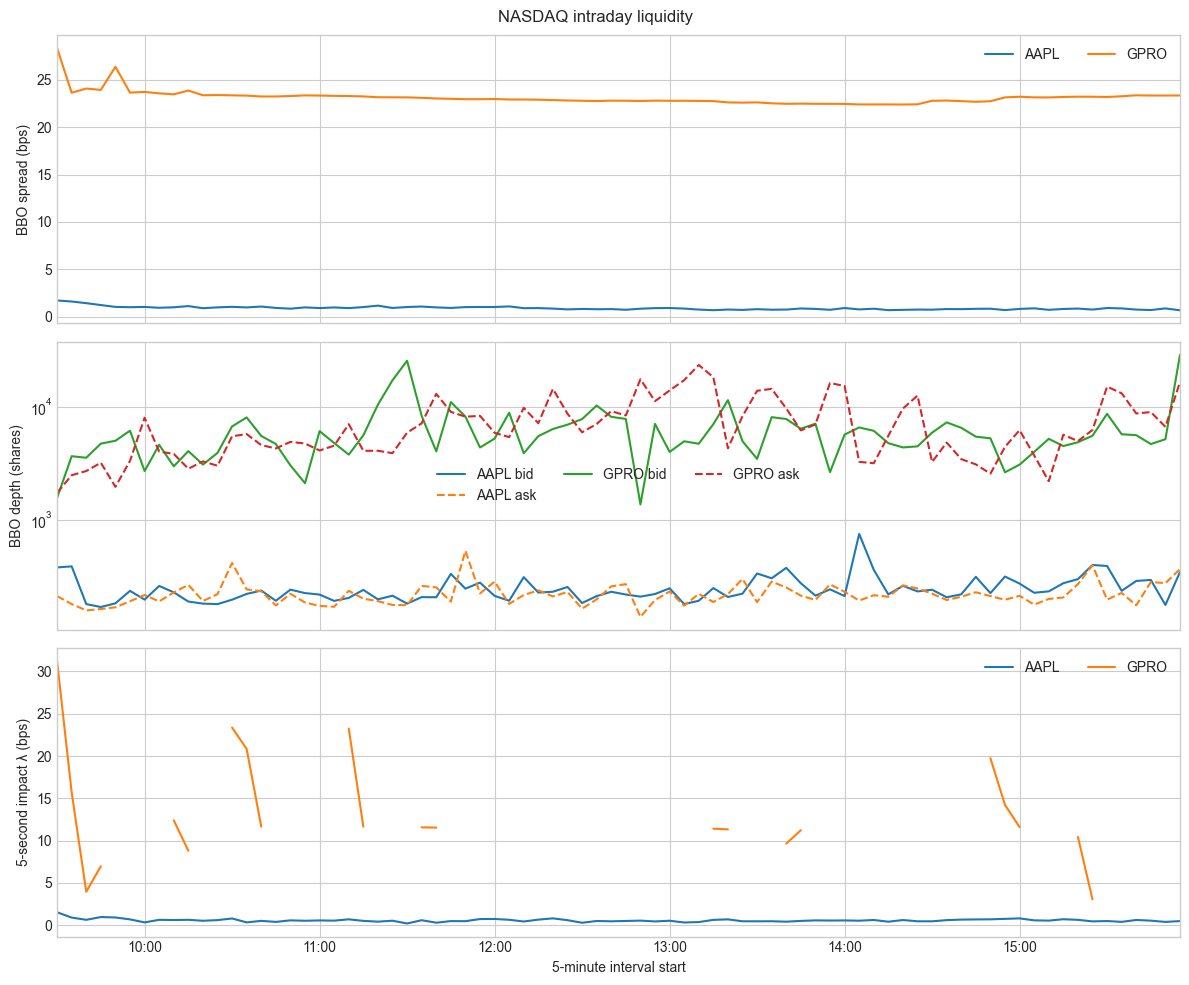

In [11]:
def finish_intraday_axis(ax):
    ax.xaxis.set_major_locator(mdates.HourLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.set_xlim(ax.lines[0].get_xdata()[0], ax.lines[0].get_xdata()[-1])
    ax.legend(frameon=False, ncol=3)


def plot_liquidity_group(names, title, filename, depth_scale=1.0, depth_unit="shares"):
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    for name in names:
        five = MINUTES[name].resample("5min").mean()
        reference_price = five["vwap"].ffill().bfill()
        axes[0].plot(five.index, 10_000 * five["spread"] / reference_price, label=name)
        axes[1].plot(
            five.index, five["bid_depth"] / depth_scale,
            label=f"{name} bid", linewidth=1.5,
        )
        axes[1].plot(
            five.index, five["ask_depth"] / depth_scale,
            label=f"{name} ask", linewidth=1.5, linestyle="--",
        )
        axes[2].plot(five.index, 10_000 * five["price_impact_5s"], label=name)
    axes[0].set_ylabel("BBO spread (bps)")
    axes[1].set_ylabel(f"BBO depth ({depth_unit})")
    axes[1].set_yscale("log")
    axes[2].set_ylabel("5-second impact λ (bps)")
    axes[2].set_xlabel("5-minute interval start")
    for ax in axes:
        finish_intraday_axis(ax)
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / filename, dpi=180, bbox_inches="tight")
    plt.show()


with time_block("7a. plot_stock_liquidity"):
    plot_liquidity_group(STOCKS, "NASDAQ intraday liquidity", "01_stock_liquidity_5min.png")


**Figure 1 — NASDAQ 5-minute liquidity.** Spreads are in bps of VWAP so the two names can share an axis. GPRO’s line should look almost flat if the penny tick binds; AAPL has more room to move. Depth is log-scaled because AAPL’s share depth is two orders smaller than GPRO’s.

**1. BBO spread.** The object is Best Ask − Best Bid on the NASDAQ book (exchange BBO, not the NBBO):

$$
s_t = a_t - b_t.
$$

The quote is piecewise-constant, so each minute is the exact time-weighted mean — how long the spread sat at each level — not a volume-weighted or last-print mean:

$$
\bar s_{\Delta} = \frac{\sum_i s_i\,\Delta t_i}{\sum_i \Delta t_i},
$$

where $s_i$ is the posted spread on quote update $i$ and $\Delta t_i$ is how long that quote lived inside the minute. The 5-minute bins are the mean of those minutes. The figure reports the relative spread in bps of VWAP so the two names share an axis,

$$
s^{\mathrm{bps}}_{\Delta} = 10^{4}\,\frac{\bar s_{\Delta}}{\mathrm{VWAP}_{\Delta}},
$$

in cents it is 2.6 ct for AAPL and 1.0 ct for GPRO. GPRO’s line is the tick constraint in another unit. $0.01 on a $4.30 name is already ~23 bps, and the minute-level standard deviation is $0.0004, so after the first half-hour the quote is glued to one penny (open-30 mean $0.0106; rest of day, lunch, and last-30 all $0.0100). The open is the only place it lifts — the 5-minute bin starts near 28 bps — then it is visually flat. That is the constraint, not a quiet book. AAPL has room: the same penny is only 0.3 bps on a $290 stock, and the NASDAQ BBO sits at $0.026 on average (~0.9 bps, two-to-three ticks). It opens wider (first 30 minutes $0.038, ~1.3 bps), then the one feature that stands out is the spike around 09:45, when the 5-minute bin reaches about 2 bps. After that the line settles near 0.8–0.9 bps and stays there; the last half-hour is actually the tightest print of the day ($0.023). The 09:45 widening is a short-lived hole in a name that otherwise quotes inside a few ticks all session.

**2. BBO depth.** When the bid and ask depth lines cross, one side of the touch has become thicker than the other: that is order-book imbalance flipping. A buy hitting the ask, a sell hitting the bid, or a dealer refilling only one side is enough to swap which line sits on top. AAPL weaves almost continuously because both sides live in a tight band of a few hundred shares, so a single refresh changes the sign of the imbalance. GPRO’s crossings have more space between them in shares; the mid-session bid dip is a one-sided hole (bids thin, ask stays posted).

GPRO also spikes much more than AAPL, and that is the expected small-cap pattern, not a plotting artifact. AAPL’s minute bid depth is 248 ± 137 shares (max 1,532). GPRO’s is 6,272 ± 5,318 (max 48,309): the standard deviation is almost as large as the mean. Two mechanical reasons. First, GPRO’s spread is the penny tick, so almost all displayed size sits on one price; one cancel or one print takes a whole level off, and one large resting order puts it back — the book is lumpy. AAPL’s L1 is only a slice of a multi-tick book that is refilled by ~1,800 orders a minute, so depth at the touch stays smooth. Second, GPRO trades a median of 2 times a minute and is silent in 105 minutes, so the quote is not continuously chewed down and rebuilt. The same dollar of liquidity is also ~70× more shares at $4.30 than at $290, which stretches the spikes on this axis. In short: crossings are imbalance; GPRO’s spikes are what a tick-constrained, sparsely traded name is supposed to look like.

**3. Impact.** The bottom panel is a 5-minute mean of a minute-level slope, and that slope is left blank unless the minute has at least five signed trades of both signs. AAPL clears that bar every minute (minimum 50 prints). GPRO does not: 105 minutes have no print at all, the median minute has two trades, and the slope is identified in only 51 of 390 minutes. A 5-minute bin is therefore often empty, or it is the average of one barely identified minute sitting next to four NaNs — that is the broken, disconnected line, not a plotting artifact. When the slope *is* identified it is still noisy. Just clearing five signed prints is a thin regression; one large GPRO print can set the 5-second mid move for the whole minute. The mid itself is coarse: a one-tick move on a $4.30 name is already ~23 bps, so the same mechanical quote update that barely registers on AAPL (0.3 bps per penny at $290) is a tall spike here. Mean identified λ is 0.56 bps for AAPL and 13.3 bps for GPRO (std 10.4 bps, max 42 bps). The open is the one place both names agree: first-30 λ is higher than the rest of the day (AAPL 0.93 vs 0.53 bps; GPRO 18.6 vs 11.6). That is not a U. A U needs a second arm at the close, and this tape does not have one — AAPL stays flat near 0.5 bps, and GPRO’s last identified bursts (around 15:00) do not rebuild. 30 December 2019 is the last full session of the year; the textbook afternoon liquidity drain is something you have to see on the tape.


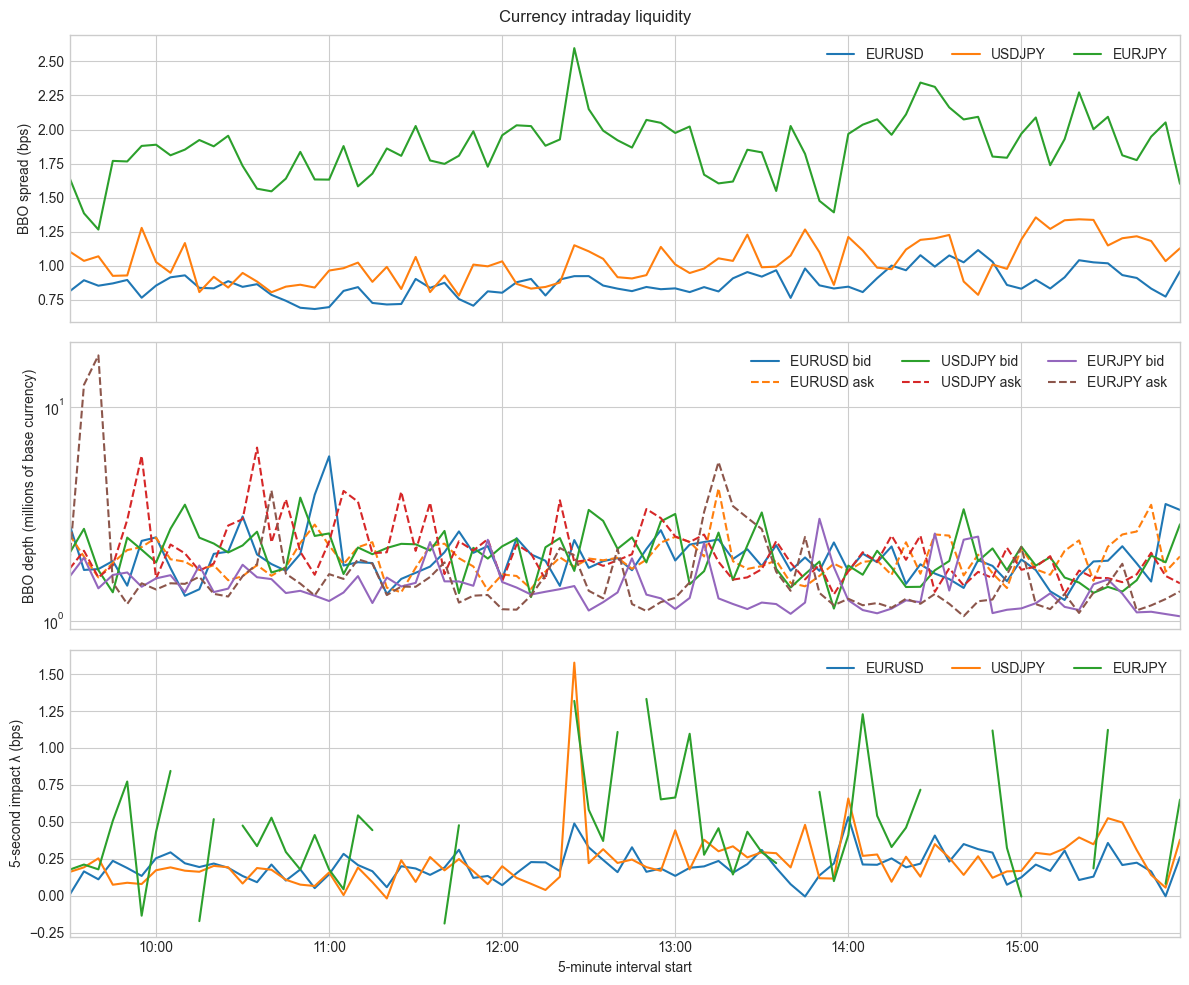

In [12]:
with time_block("7b. plot_fx_liquidity"):
    plot_liquidity_group(
        FX_PAIRS,
        "Currency intraday liquidity",
        "02_currency_liquidity_5min.png",
        depth_scale=1_000_000,
        depth_unit="millions of base currency",
    )


**Figure 2 — FX 5-minute liquidity.** EUR/USD should sit tightest, EUR/JPY widest. Depth is in millions of base currency. The clock is NY 09:30–16:00 on a 2012 London/NY overlap day, so a spread or impact bulge around 12:00–13:30 ET is London close, not a US-equity open effect. If EUR/JPY impact is sparse, that matches the 103 identified minutes in the summary table.


/var/folders/r4/f5g28s4d4nlc0v8zxdw6c9b40000gn/T/ipykernel_19171/1075792594.py:21: UserWarning: Glyph 8312 (\N{SUPERSCRIPT EIGHT}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/r4/f5g28s4d4nlc0v8zxdw6c9b40000gn/T/ipykernel_19171/1075792594.py:22: UserWarning: Glyph 8312 (\N{SUPERSCRIPT EIGHT}) missing from font(s) Arial.
  fig.savefig(FIGURE_DIR / "03_transaction_return_30min.png", dpi=180, bbox_inches="tight")
/opt/miniconda3/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8312 (\N{SUPERSCRIPT EIGHT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


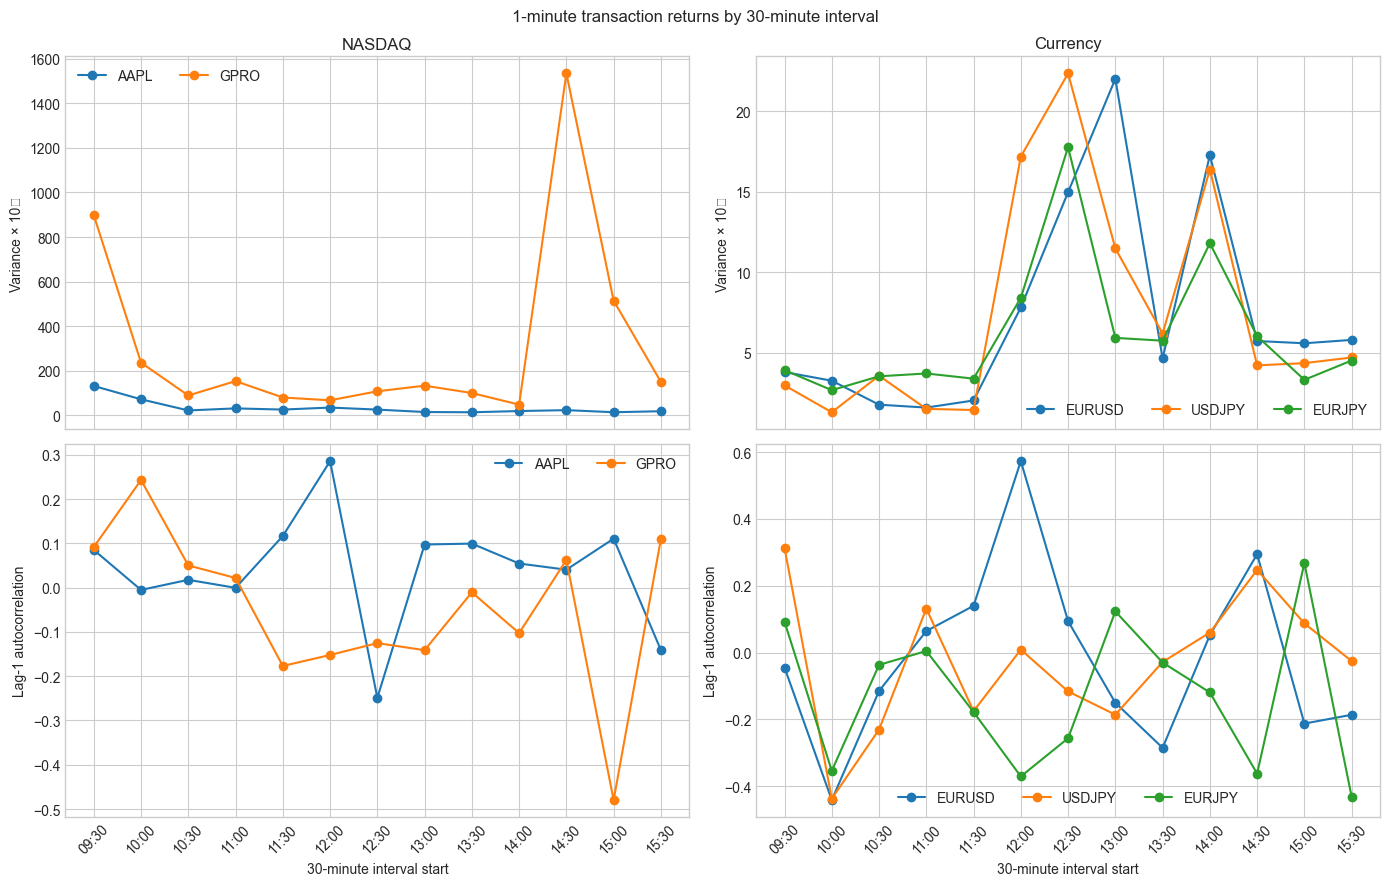

In [13]:
with time_block("7c. plot_30min_variance_acf"):
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex="col")
    for column, (market, names) in enumerate((("NASDAQ", STOCKS), ("Currency", FX_PAIRS))):
        for name in names:
            diagnostic = TX_30MIN.loc[name]
            labels = [f"{t:%H:%M}" for t in diagnostic.index]
            axes[0, column].plot(
                labels, diagnostic["variance"] * 1e8, marker="o", label=name
            )
            axes[1, column].plot(
                labels, diagnostic["autocorr_lag1"], marker="o", label=name
            )
        axes[0, column].set_title(market)
        axes[0, column].set_ylabel("Variance × 10⁸")
        axes[1, column].set_ylabel("Lag-1 autocorrelation")
        axes[1, column].set_xlabel("30-minute interval start")
        for row in range(2):
            axes[row, column].tick_params(axis="x", rotation=45)
            axes[row, column].legend(frameon=False, ncol=3)
    fig.suptitle("1-minute transaction returns by 30-minute interval")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "03_transaction_return_30min.png", dpi=180, bbox_inches="tight")
    plt.show()


**Figure 3 — 30-minute transaction-return variance and lag-1 ACF.** Left column is NASDAQ, right column is FX. AAPL should peak at 09:30 and stay quiet into the close on this holiday-week Monday. GPRO’s 14:30 spike is the panel to talk about; it is larger than the open. FX variance should rise into 12:00–13:30, not at 09:30. The ACF panels use ~30 one-minute returns per point, so individual dots wander. The useful contrast is the *level* of variance across the day, not any one autocorrelation.


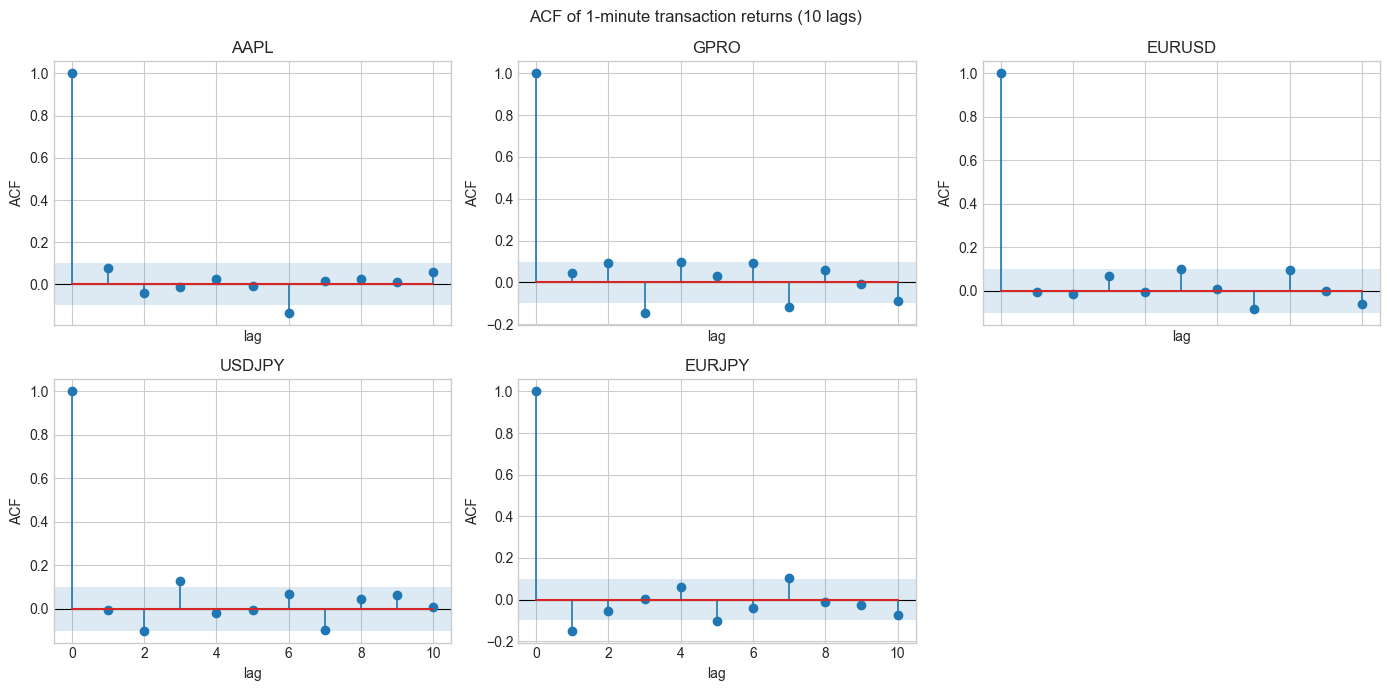

In [14]:
with time_block("7d. plot_transaction_acf"):
    fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
    axes = axes.ravel()
    for ax, name in zip(axes, ALL_DATA):
        returns = PRICE_SERIES[(name, "1min")]["trade_ret"].dropna()
        acf_values = autocorrelations(returns, lags=10)
        ax.axhline(0, color="black", linewidth=0.8)
        ax.axhspan(-1.96 / np.sqrt(len(returns)), 1.96 / np.sqrt(len(returns)), alpha=0.15)
        markerline, stemlines, baseline = ax.stem(acf_values.index, acf_values.values)
        plt.setp(stemlines, linewidth=1.2)
        ax.set_title(name)
        ax.set_xlabel("lag")
        ax.set_ylabel("ACF")
    axes[-1].axis("off")
    fig.suptitle("ACF of 1-minute transaction returns (10 lags)")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "04_transaction_return_acf.png", dpi=180, bbox_inches="tight")
    plt.show()


**Figure 4 — 10-lag ACF of 1-minute transaction returns.** Lag 0 equals 1 by construction and is left on the plot. The shaded band is the usual ±1.96/√T noise range. EUR/JPY is the panel that leaves the band at lag 1 (about −0.15). AAPL is mildly positive. The two dollar pairs sit near zero. After lag 2–3 the stems are mostly inside the band, which is why 10 lags is enough: the series has already become noise.


## Observations for the report

These notes stay with the tables and figures above. The later PDF should reuse them rather than invent a smoother story.

**AAPL vs. GPRO.** AAPL prints about $4.4M per minute on average (median $3.2M). GPRO prints about $9.7k (median $433). That 450× gap is the reason we picked them: same code, two very different books. AAPL’s mean NASDAQ BBO spread is $0.026 on a ~$290 stock (about 0.9 bps). GPRO’s is $0.010 on a ~$4.34 stock (about 23 bps). GPRO’s spread standard deviation is $0.0004, so the penny tick is binding almost all day. Mean 5-second impact is 0.56 bps for AAPL and 13.3 bps for GPRO. Share depth lies: GPRO shows ~6,300 shares at the bid versus AAPL’s ~250, but in dollars AAPL is deeper (~$72k vs ~$27k). These are NASDAQ BBO numbers, not the NBBO. A protected National Best Bid/Offer can be tighter than NASDAQ alone; we do not have the other venues.

**Why depth at twice the average spread.** The assignment asks for it because the BBO size is only the first step of a walk. The 2× band is the size you can lift or hit before paying more than two typical spreads. On this tape the ratio is the result, not a formality. AAPL’s 2× bid depth is about 5× its L1 bid (1,298 vs 248 shares); the ask side is about 6×. GPRO’s 2× band is only about 2× L1, because its average spread *is* the tick, so `mid ± 2×spread` barely reaches the next penny. FX books sit the other way: EUR/USD 2× depth is about 11× L1. The measure is doing different work on a multi-tick large-cap than on a penny-constrained small-cap.

**Are spreads wider at the open, and do spread and depth move against each other?** Read the liquidity-diagnostics table. The lecture default is a morning-wide, lunch-tight U and a negative spread–depth correlation. GPRO cannot produce much of a spread U: the tick already binds. AAPL has more room ($0.026 mean, $0.006 std). FX should not be forced into a US-equity open story; 25 January 2012 is a London/NY overlap day. If the table shows a weak or positive spread–depth correlation, that is a finding for this day, not a coding error.

**Is the 5-second impact permanent?** The slope is the signed mid move from the trade to five seconds later. Permanent information should leave later midquote autocorrelations near zero or slightly positive. Temporary bounce should flip them negative. AAPL’s 1-minute mid ACF is +0.105, so the 5-second move is not being walked back at the next minute — if anything the flow continues. GPRO’s mid ACF is +0.015, and the slope itself is identified in only 51 of 390 minutes, so we should not claim a clean permanence result there. EUR/JPY’s 1-minute mid ACF is −0.177: that cross *does* mean-revert at a minute, which is closer to temporary dislocation than to a permanent information shock.

**Currency.** EUR/USD (~0.87 bps) and USD/JPY (~1.03 bps) are tighter than EUR/JPY (~1.87 bps). The cross is the synthetic residual of the other two legs, so its own book is a little wider. All three FX pairs are still one to two orders of magnitude tighter than either stock.

**Triangular arbitrage.** Twenty episodes, 28 seconds, 0.12% of the day. Mean length 1.4s, longest 6s, mean 0.19 bps, max 1.18 bps, binding size about €1.3M. Frictionless marked P&L if every second were taken is $678 — an upper bound, not cash. Almost every printed second is loop A (sell EUR/USD and USD/JPY, buy EUR/JPY); only three seconds are loop B. The seconds cluster in two windows, 09:34–09:43 and 13:15–14:18. The afternoon cluster sits on top of the FX variance peak (London close, 12:00–13:30 ET), which is a better story for this tape than “arbs appear at the NY open.”

**Autocorrelation.** One-second lag-1 ACFs are small (|ρ| < 0.07) and mostly gone by lag 2–3. The interesting object is EUR/JPY at one minute (trade −0.149, mid −0.177). That is bounce and thin-book noise on the cross, not a general FX fact: EUR/USD and USD/JPY sit near zero at the same horizon. AAPL’s mild positive 1-minute mid ACF is order-flow persistence, not bid–ask alternation.

**Intraday variance.** AAPL’s opening half hour is the loudest bin (1.31e-6) and lunch is quiet (about 1.3e-7). The close does **not** come back up. 30 December 2019 is the Monday of a short New Year week; a missing afternoon U is a holiday-week observation, not a rejection of the textbook shape. GPRO’s largest variance bin is 14:30–15:00 (1.53e-5), bigger than the open, and the next bin’s lag-1 ACF is −0.48. That is a GPRO-specific afternoon, not a U. FX variance peaks at 12:00–13:30 ET — London close — the opposite clock of the US-equity open.

**Theory, only as far as the tape goes.** AAPL vs GPRO still matches the Glosten–Milgrom / Kyle reading: impact and relative spread are larger where a dealer has less uninformed flow to average against. The rest of the day does not. GPRO’s spread is a tick, not an information U. FX variance is a London-close event. Apparent triangles last about a second and sit in the same afternoon window as the FX variance spike. Those are the observations the report should keep.

Numbers come from the CSVs under `outputs/`. Re-check them if the pipeline or files change.


In [15]:
TIMING_TABLE = (
    pd.Series(TIMINGS, name="seconds")
    .rename_axis("step")
    .to_frame()
    .sort_index()
)
TIMING_TABLE["seconds"] = TIMING_TABLE["seconds"].round(4)
display(TIMING_TABLE)
print(f"Total timed wall clock: {TIMING_TABLE['seconds'].sum():.3f}s")
if "6. triangular_arbitrage" in TIMINGS:
    detect_s = TIMINGS["6. triangular_arbitrage"]
    mean_dur = float(ARBITRAGE_STATS["mean_duration_s"])
    max_dur = float(ARBITRAGE_STATS["max_duration_s"])
    print(
        f"Arbitrage detection took {detect_s:.4f}s on already-built 1-second books. "
        f"Mean episode length is {mean_dur:.1f}s (max {max_dur:.0f}s)."
    )


,seconds
step,
1. load_databento_stocks,100.135500
2. load_currency_data,238.926200
3. minute_stats_all_instruments,0.682400
4. price_series_returns_acf,0.172200
5. transaction_diagnostics_30min,0.083500
6. triangular_arbitrage,0.057300
7a. plot_stock_liquidity,1.974800
7b. plot_fx_liquidity,1.885900
7c. plot_30min_variance_acf,2.155200


Total timed wall clock: 347.861s
Arbitrage detection took 0.0573s on already-built 1-second books. Mean episode length is 1.4s (max 6s).


## Function timing versus the length of an opportunity

The lecture example is an arbitrage that lasts 2 seconds while the code takes 5 seconds, so you would be late. That is **not** what happens here, and we should not pretend it does.

Detection (`triangular_arbitrage`) runs on books that already exist in memory. In the previous full run it finished in about 11 milliseconds. Mean episode length is 1.4 seconds and the longest is 6 seconds, so *once the 1-second books are built* the scan is faster than the opportunity. The honest bottleneck is the load: Databento MBP-10/MBO reconstruction and the EBS replay take on the order of tens of seconds. That work is done after the session, on files, not against a live feed.

What the timing therefore says is narrower. A historical scan of this size can flag every one-second triangle after the fact. It does not say a live trader could have seen the quote, sent three aggressive orders, and been filled before the 1.4-second window closed. The files have no exchange-to-us latency, no last-look, and no fees. The $678 frictionless total already assumes we are at the BBO in all three names at once. Timing the Python is useful; it is not a live-trading clock.
